# Sentinel-2 image and rasters processing notebook

**Description**

This notebook is used for processing Sentinel-2 images including calculating NDVI indice and stack all rasters together. The stacked image is used as an input of deep learning model in later step.

Main steps of Sentinel-2 image and rasters processing:
1. Import data
2. Calculate NDVI
3. Stack Sentinel-2 image, Public Urban Green Spaces (PUGS) binary mask, PUGS Signed-distance transform (SDT) raster, and NDVI raster together

**Input files**

4 files
- Sentinel-2 image (`cm_sentinel2_l1c_openeo_med_4months_dresden.geotiff`)
- PUGS binary mask from OSM (`public_green_spaces_dresden.geotiff`)
- PUGS SDT raster (`sdt_public_green_spaces_dresden.geotiff`)
- Dresden administrative boundary (`dresden_boundary.geojson`)

**Output files**

2 files
- Stacked raster (`stacked_sentinel2_dresden.geotiff`)
- Stackd raster clip to Dresden boundary (`stacked_sentinel2_dresden_clipped.geotiff`)

**Requirements/Dependencies**

This notebook requires user to run the following notebooks first: 
- 1_data_acquisition_satellite_image.ipynb
- 1_data_acquisition_osm.ipynb
- 2_data_processing_osm.ipynb

In case all the input data required in this notebook are available, user can directly run this notebook without running the notebooks in the list.

# 1. Import libraries and load config

In [1]:
import os
import sys

# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)

In [2]:
import rioxarray
import rasterio
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import yaml
import geopandas as gpd
from pugs_detection.raster import contrast_stretch_dn, min_max_normalize

In [3]:
# Load config
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# 2. Set variables

In [4]:
sentinel2_path = config["paths"]["raw_sentinel_path"]
osm_binary_mask_path = config["paths"]["pugs_mask_path"]
sdt_path = config["paths"]["pugs_sdt_path"]
dresden_boundary_path = config["paths"]["dresden_boundary_path"]
clipped_output_path = config["paths"]["clipped_image_path"]
output_dir = config["paths"]["processed_sentinel_path"]
og_output_path = config["paths"]["whole_image_path"]

# 3. Import Sentinel-2 image

In [5]:
data = rioxarray.open_rasterio(sentinel2_path, masked=True)

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

## Explore value

In [6]:
# Print resolution for each band
for i in range(data.sizes["band"]):
    band = data.sel(band=i + 1)
    # Get resolution from transform
    if hasattr(band, "rio"):
        res = band.rio.resolution()
        print(f"Band {i + 1} resolution: {res} meters")

Band 1 resolution: (10.0, -10.0) meters
Band 2 resolution: (10.0, -10.0) meters
Band 3 resolution: (10.0, -10.0) meters
Band 4 resolution: (10.0, -10.0) meters
Band 5 resolution: (10.0, -10.0) meters
Band 6 resolution: (10.0, -10.0) meters
Band 7 resolution: (10.0, -10.0) meters
Band 8 resolution: (10.0, -10.0) meters
Band 9 resolution: (10.0, -10.0) meters
Band 10 resolution: (10.0, -10.0) meters
Band 11 resolution: (10.0, -10.0) meters
Band 12 resolution: (10.0, -10.0) meters
Band 13 resolution: (10.0, -10.0) meters


## Normalize Sentinel-2 image values to [0,1] range

Divide the pixel value by 10000 and clip it to 0 to 1 range

In [7]:
processed_sat_img = contrast_stretch_dn(data)

In [8]:
print(processed_sat_img.min().values)
print(processed_sat_img.max().values)

0.0
1.0


# 4. Import binary mask

In [9]:
binary_mask_pugs = rioxarray.open_rasterio(osm_binary_mask_path)

In [10]:
binary_mask_pugs = binary_mask_pugs.assign_coords(band=[14])
binary_mask_pugs

<xarray.DataArray (band: 1, y: 2301, x: 2747)> Size: 13MB
[6320847 values with dtype=int16]
Coordinates:
  * x            (x) float64 22kB 4.003e+05 4.003e+05 ... 4.277e+05 4.277e+05
  * y            (y) float64 18kB 5.671e+06 5.671e+06 ... 5.648e+06 5.648e+06
    spatial_ref  int64 8B 0
  * band         (band) int64 8B 14
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

# 5. Import SDT raster

In [11]:
sdt_pugs = rioxarray.open_rasterio(sdt_path)

In [12]:
sdt_pugs = sdt_pugs.assign_coords(band=[15])
sdt_pugs

<xarray.DataArray (band: 1, y: 2301, x: 2747)> Size: 51MB
[6320847 values with dtype=float64]
Coordinates:
  * x            (x) float64 22kB 4.003e+05 4.003e+05 ... 4.277e+05 4.277e+05
  * y            (y) float64 18kB 5.671e+06 5.671e+06 ... 5.648e+06 5.648e+06
    spatial_ref  int64 8B 0
  * band         (band) int64 8B 15
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

## Normalize SDT values to [-1,1] range

In [13]:
# Check the range of your SDT values
print("SDT min:", sdt_pugs.min().values, ", SDT max:", sdt_pugs.max().values)

normalized_sdt_pugs = sdt_pugs.copy()
# Apply normalization
normalized_sdt_pugs.values = min_max_normalize(sdt_pugs)

SDT min: -252.20031720836514 , SDT max: 91.76055797563569


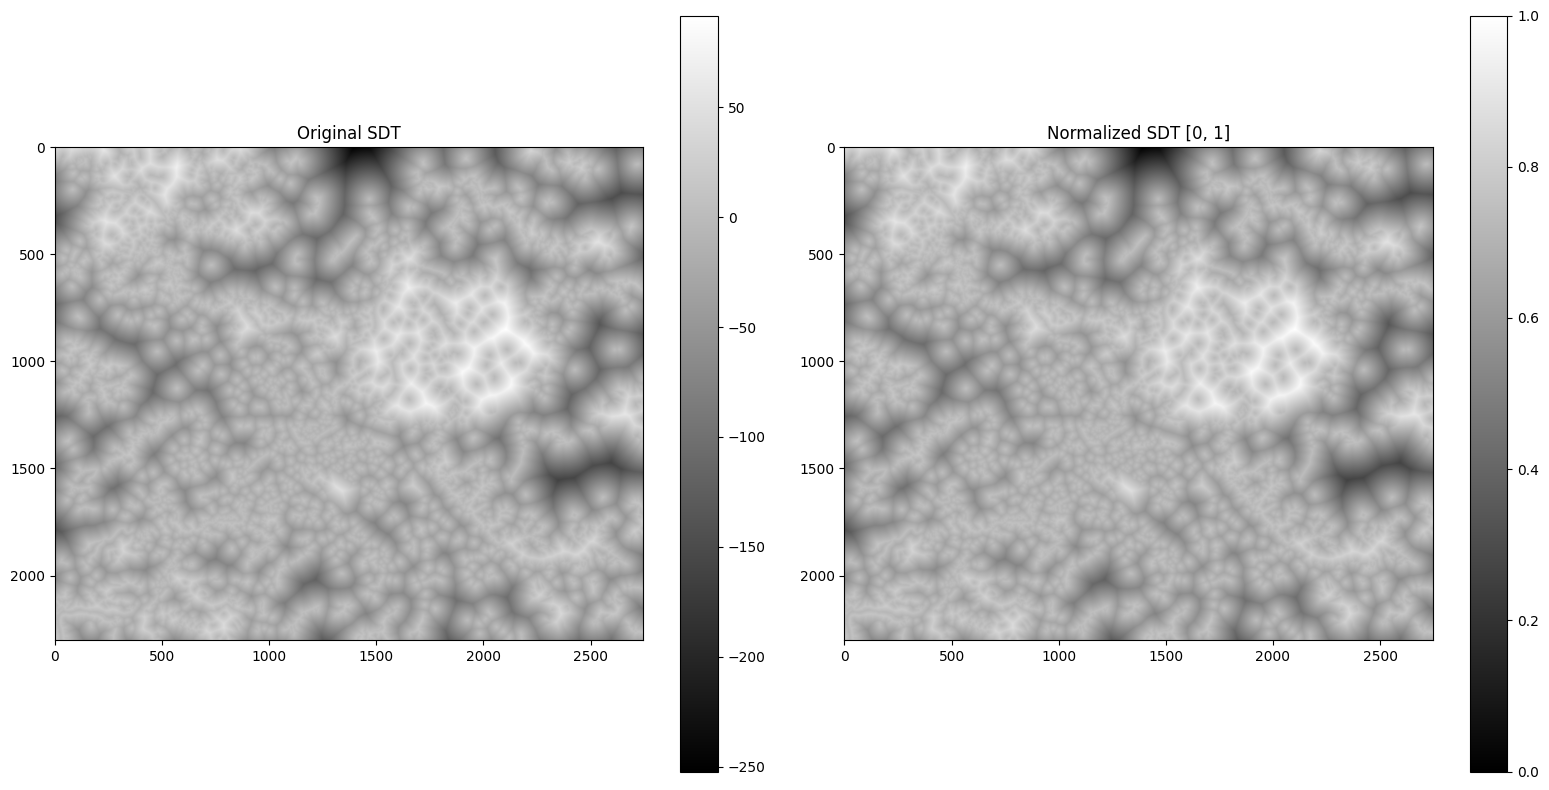

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Original SDT
im1 = ax1.imshow(sdt_pugs.squeeze(), cmap="gray")
ax1.set_title("Original SDT")
plt.colorbar(im1, ax=ax1)

# Normalized SDT
im2 = ax2.imshow(normalized_sdt_pugs.squeeze(), cmap="gray")
ax2.set_title("Normalized SDT [0, 1]")
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

# 6. Calculate NDVI

NDVI min: -0.3626763 NDVI max: 1.0


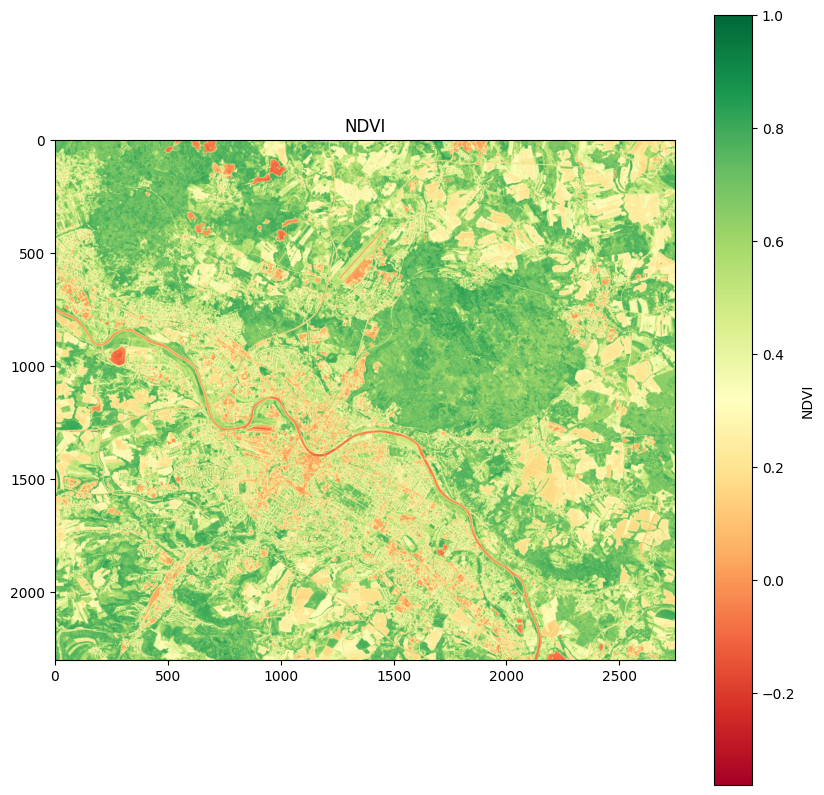

In [15]:
red = processed_sat_img.sel(band=4)
nir = processed_sat_img.sel(band=8)

# Calculate NDVI
ndvi = (nir - red) / (nir + red)
# Interpolate NaN values
# ndvi = ndvi.fillna(0)
ndvi = ndvi.interpolate_na(dim="x")
ndvi = ndvi.expand_dims("band").assign_coords(band=[16])

print("NDVI min:", ndvi.min().values, "NDVI max:", ndvi.max().values)

# Plot the NDVI
plt.figure(figsize=(10, 10))
plt.imshow(ndvi.sel(band=16), cmap="RdYlGn")
plt.colorbar(label="NDVI")
plt.title("NDVI")
plt.show()

# 7. Stack Sentinel-2 image and indices in one file

In [16]:
stacked_img = xr.concat(
    [processed_sat_img, binary_mask_pugs, normalized_sdt_pugs, ndvi], dim="band"
)

In [17]:
# Check for NaNs in input bands
for i in range(stacked_img.shape[0]):
    print(f"Min value {i + 1}: {stacked_img.sel(band=i + 1).min().values}")
    print(f"Max value {i + 1}: {stacked_img.sel(band=i + 1).max().values}")
    print(f"NaN values {i + 1}: {np.isnan(stacked_img.sel(band=i + 1)).sum().values}")
    print()

Min value 1: 0.09969999641180038
Max value 1: 0.4296000003814697
NaN values 1: 0

Min value 2: 0.05810000002384186
Max value 2: 1.0
NaN values 2: 0

Min value 3: 0.0
Max value 3: 1.0
NaN values 3: 0

Min value 4: 0.0
Max value 4: 1.0
NaN values 4: 0

Min value 5: 0.0
Max value 5: 1.0
NaN values 5: 0

Min value 6: 0.022099999710917473
Max value 6: 1.0
NaN values 6: 0

Min value 7: 0.024700000882148743
Max value 7: 1.0
NaN values 7: 0

Min value 8: 0.024399999529123306
Max value 8: 1.0
NaN values 8: 0

Min value 9: 0.02019999921321869
Max value 9: 1.0
NaN values 9: 0

Min value 10: 0.006200000178068876
Max value 10: 0.17339999973773956
NaN values 10: 0

Min value 11: 0.0006000000284984708
Max value 11: 0.002300000051036477
NaN values 11: 0

Min value 12: 0.009200000204145908
Max value 12: 1.0
NaN values 12: 0

Min value 13: 0.00419999985024333
Max value 13: 1.0
NaN values 13: 0

Min value 14: 0.0
Max value 14: 1.0
NaN values 14: 0

Min value 15: 0.0
Max value 15: 1.0
NaN values 15: 0

Mi

# 8. Clipped image to dresden boundary

In [18]:
boundary_gdf = gpd.read_file(dresden_boundary_path)

if boundary_gdf.crs != stacked_img.rio.crs:
    boundary_gdf = boundary_gdf.to_crs(stacked_img.rio.crs)

clipped_image = stacked_img.rio.clip(boundary_gdf.geometry.values, boundary_gdf.crs)

In [19]:
# Check for NaNs in input bands
for i in range(clipped_image.shape[0]):
    print(f"Min value {i + 1}: {clipped_image.sel(band=i + 1).min().values}")
    print(f"Max value {i + 1}: {clipped_image.sel(band=i + 1).max().values}")
    print(f"NaN values {i + 1}: {np.isnan(clipped_image.sel(band=i + 1)).sum().values}")
    print()

Min value 1: 0.09969999641180038
Max value 1: 0.4296000003814697
NaN values 1: 2855105

Min value 2: 0.05810000002384186
Max value 2: 1.0
NaN values 2: 2855105

Min value 3: 0.0
Max value 3: 1.0
NaN values 3: 2855105

Min value 4: 0.0
Max value 4: 1.0
NaN values 4: 2855105

Min value 5: 0.0
Max value 5: 1.0
NaN values 5: 2855105

Min value 6: 0.022099999710917473
Max value 6: 1.0
NaN values 6: 2855105

Min value 7: 0.024700000882148743
Max value 7: 1.0
NaN values 7: 2855105

Min value 8: 0.024399999529123306
Max value 8: 1.0
NaN values 8: 2855105

Min value 9: 0.02019999921321869
Max value 9: 1.0
NaN values 9: 2855105

Min value 10: 0.006800000090152025
Max value 10: 0.1445000022649765
NaN values 10: 2855105

Min value 11: 0.0006000000284984708
Max value 11: 0.002300000051036477
NaN values 11: 2855105

Min value 12: 0.009399999864399433
Max value 12: 1.0
NaN values 12: 2855105

Min value 13: 0.00559999980032444
Max value 13: 1.0
NaN values 13: 2855105

Min value 14: 0.0
Max value 14: 1

# 9. Save file

## Save clipped image

In [20]:
try:
    os.makedirs(output_dir)
except FileExistsError:
    # Directory already exists
    pass

# Prepare data
array_data = clipped_image.values
height, width = array_data.shape[1], array_data.shape[2]
bands = array_data.shape[0]
transform = clipped_image.rio.transform()
crs = clipped_image.rio.crs

with rasterio.open(
    clipped_output_path,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=bands,
    dtype="float32",  # Force float32
    crs=crs,
    transform=transform,
    nodata=-9999,
) as dst:
    # Write each band with explicit float handling
    for i in range(bands):
        # Ensure this band is float32
        band_data = array_data[i].astype("float32")
        dst.write(band_data, i + 1)

## Save regular image (no clipping)

In [21]:
# Save image without clipping using rasterio

# Convert to numpy array
data_array = stacked_img.values
height, width = data_array.shape[1], data_array.shape[2]
bands = data_array.shape[0]

# Get geotransform and projection from xarray
transform = stacked_img.rio.transform()
crs = stacked_img.rio.crs

# Define rasterio profile
profile = {
    'driver': 'GTiff',
    'height': height,
    'width': width,
    'count': bands,
    'dtype': 'float32',
    'crs': crs,
    'transform': transform,
    'nodata': -9999
}

with rasterio.open(og_output_path, 'w', **profile) as dst:
    for i in range(bands):
        dst.write(data_array[i].astype('float32'), i+1)

# 10. Open the saved file

In [22]:
data = rioxarray.open_rasterio(clipped_output_path, masked=True)

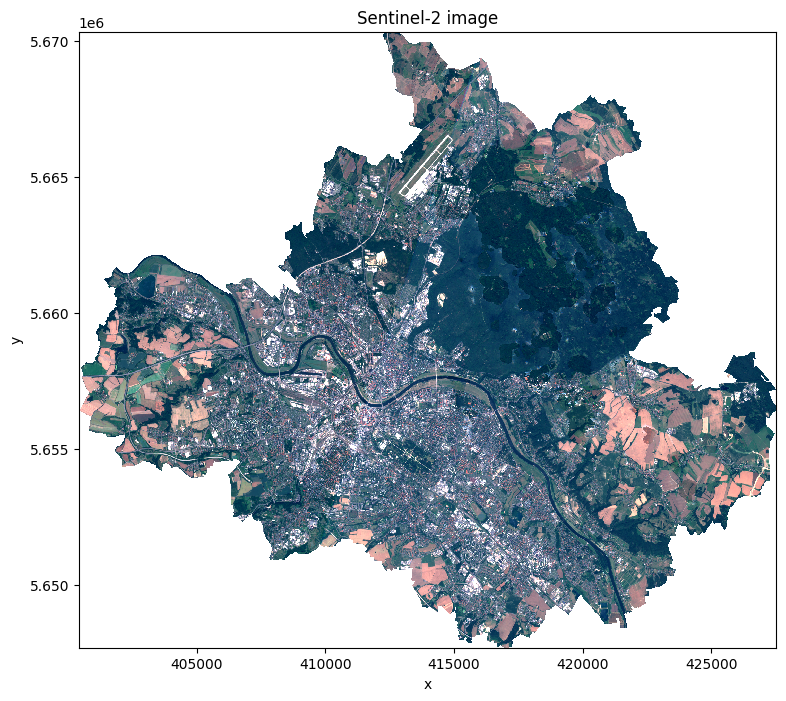

In [23]:
# Plot the raster data
plt.figure(figsize=(9, 8))
data.sel(band=[4, 3, 2]).plot.imshow(robust=True)
plt.title("Sentinel-2 image")
plt.show()

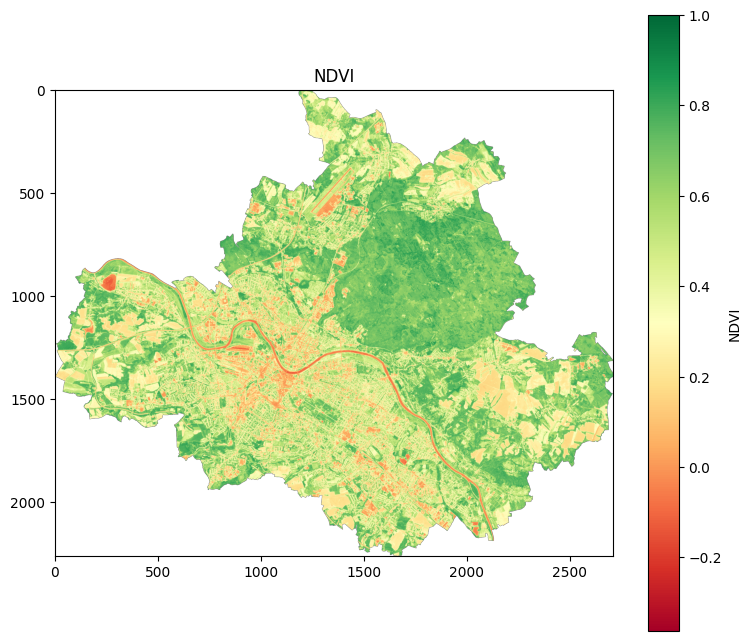

In [24]:
# Plot the raster data
plt.figure(figsize=(9, 8))
plt.imshow(data.sel(band=16), cmap="RdYlGn")
plt.title("NDVI")
plt.colorbar(label="NDVI")
plt.show()

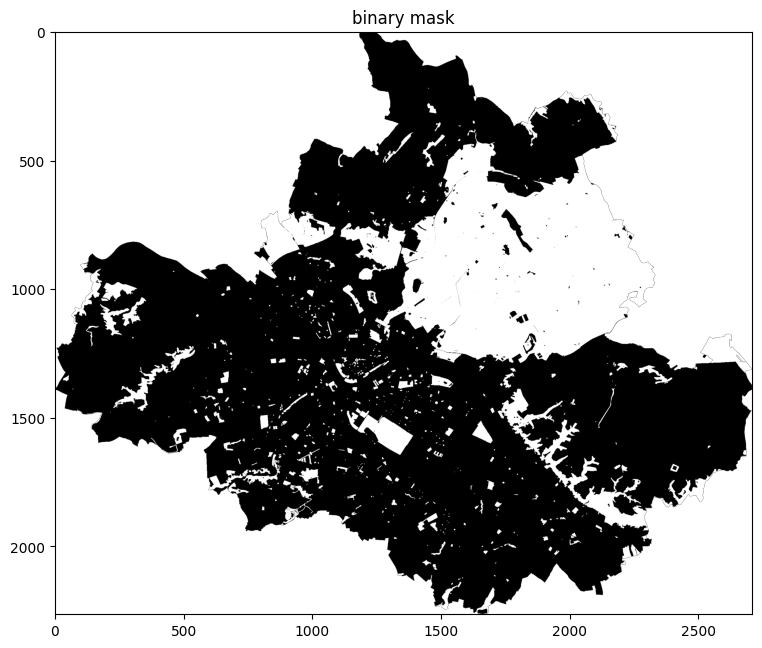

In [25]:
# Plot the raster data
plt.figure(figsize=(9, 8))
plt.imshow(data.sel(band=14), cmap="gray")
plt.title("binary mask")
plt.show()

In [31]:
# Count pixels with values 0, 1, and no_data
binary_mask = data.sel(band=14).values
zero_pixels = np.sum(binary_mask == 0)
one_pixels = np.sum(binary_mask == 1)
nan_pixels = np.isnan(binary_mask).sum()  # Count NaN values

# Print the results
print(f"Binary mask statistics:")
print(f"- Number of pixels with value 0: {zero_pixels:,}")
print(f"- Number of pixels with value 1: {one_pixels:,}")
print(f"- Total pixels: {binary_mask.size:,}")
print(f"- Percentage of 1s: {(one_pixels/binary_mask.size)*100:.2f}%")

Binary mask statistics:
- Number of pixels with value 0: 2,464,829
- Number of pixels with value 1: 817,770
- Total pixels: 6,137,704
- Percentage of 1s: 13.32%


In [27]:
data.sel(band=15)

<xarray.DataArray (y: 2264, x: 2711)> Size: 25MB
[6137704 values with dtype=float32]
Coordinates:
    band         int64 8B 15
  * x            (x) float64 22kB 4.004e+05 4.004e+05 ... 4.275e+05 4.275e+05
  * y            (y) float64 18kB 5.67e+06 5.67e+06 ... 5.648e+06 5.648e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

SDT min: 0.117629394 , SDT max: 1.0


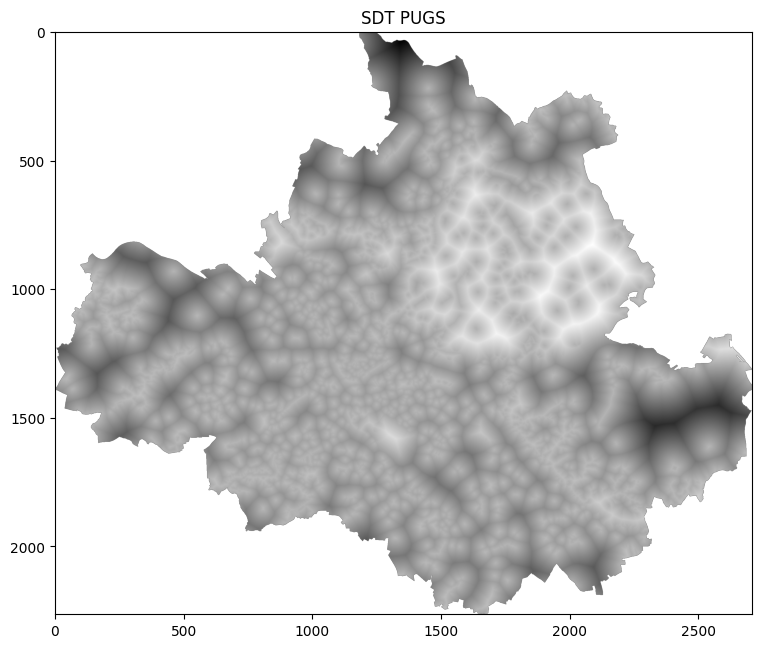

In [28]:
print(
    "SDT min:",
    data.sel(band=15).min().values,
    ", SDT max:",
    data.sel(band=15).max().values,
)
# Plot the raster data
plt.figure(figsize=(9, 8))
plt.imshow(data.sel(band=15), cmap="gray")
plt.title("SDT PUGS")
plt.show()